<a href="https://colab.research.google.com/github/yuancx2025/526_project_group2/blob/main/ds_kaggle_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Airline Price Prediction Project

**TING ZHOU**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import random

csv_path = '/content/drive/MyDrive/sample_20k.csv'

flight_sample = pd.read_csv(csv_path)
flight_sample.head()

,legId,searchDate,flightDate,startingAirport,destinationAirport,fareBasisCode,travelDuration,elapsedDays,isBasicEconomy,isRefundable,...,segmentsArrivalTimeEpochSeconds,segmentsArrivalTimeRaw,segmentsArrivalAirportCode,segmentsDepartureAirportCode,segmentsAirlineName,segmentsAirlineCode,segmentsEquipmentDescription,segmentsDurationInSeconds,segmentsDistance,segmentsCabinCode
0,8530576141585016f98030ba964493bf,2022-07-23,2022-08-03,LAX,ORD,QA7NA0MC,PT9H2M,0,False,False,...,1659544560||1659564120,2022-08-03T11:36:00.000-05:00||2022-08-03T17:0...,MSP||ORD,LAX||MSP,Delta||Delta,DL||DL,Airbus A321||Boeing 717,12960||6120,1534||341,coach||coach
1,ac0cb4ab9de6516f589c6cc98dce1713,2022-09-02,2022-09-25,ORD,LAX,NH4OAVMN,PT13H40M,1,False,False,...,1664175540||1664207400,2022-09-25T23:59:00.000-07:00||2022-09-26T08:5...,SEA||LAX,ORD||SEA,Alaska Airlines||Alaska Airlines,AS||AS,Boeing 737 MAX 9||Airbus A320,17340||10200,1723||956,coach||coach
2,13c512f43cd9ffc6f57e77ce63206350,2022-08-23,2022-08-26,DEN,CLT,E03PXP6,PT9H28M,1,False,False,...,1661591880||1661612160,2022-08-27T05:18:00.000-04:00||2022-08-27T10:5...,MCO||CLT,DEN||MCO,Frontier Airlines||Frontier Airlines,F9||F9,Airbus A321||Airbus A321,13800||6480,1549||464,coach||coach
3,348448c5dace79b376ff60555073519f,2022-07-05,2022-09-02,OAK,SFO,VH4OASMN,PT8H7M,0,False,False,...,1662156120||1662177840,2022-09-02T15:02:00.000-07:00||2022-09-02T21:0...,SEA||SFO,OAK||SEA,Alaska Airlines||Alaska Airlines,AS||AS,Boeing 737 MAX 9||Boeing 737 MAX 9,7500||7740,None||None,coach||coach
4,bde812990922ee9043c25e3ebae8e5dd,2022-05-26,2022-06-02,BOS,DFW,V7AHZNN1,PT4H20M,0,False,False,...,1654185600,2022-06-02T11:00:00.000-05:00,DFW,BOS,American Airlines,AA,Boeing 737-800,15600,1556,coach


In [ ]:
import

In [14]:
#inspect headers and engineer features
list(flight_sample.columns)

['legId',
 'searchDate',
 'flightDate',
 'startingAirport',
 'destinationAirport',
 'fareBasisCode',
 'travelDuration',
 'elapsedDays',
 'isBasicEconomy',
 'isRefundable',
 'isNonStop',
 'baseFare',
 'totalFare',
 'seatsRemaining',
 'totalTravelDistance',
 'segmentsDepartureTimeEpochSeconds',
 'segmentsDepartureTimeRaw',
 'segmentsArrivalTimeEpochSeconds',
 'segmentsArrivalTimeRaw',
 'segmentsArrivalAirportCode',
 'segmentsDepartureAirportCode',
 'segmentsAirlineName',
 'segmentsAirlineCode',
 'segmentsEquipmentDescription',
 'segmentsDurationInSeconds',
 'segmentsDistance',
 'segmentsCabinCode',
 'HHI',
 'MarketType']

In [4]:
# classifying competitions
# columns used: startingAirport, destinationAirport, segmentsAirlineCode

#flights per route per airline
route_airline = (
    flight_sample
    .groupby(['startingAirport', 'destinationAirport', 'segmentsAirlineCode'])
    .size()
    .reset_index(name='count')
)

# market share within each route
route_airline['total_route'] = (
    route_airline.groupby(['startingAirport', 'destinationAirport'])['count']
    .transform('sum')
)
route_airline['share'] = route_airline['count'] / route_airline['total_route']

# Herfindahl–Hirschman Index (HHI)
hhi = (
    route_airline
    .groupby(['startingAirport', 'destinationAirport'])['share']
    .apply(lambda s: (s**2).sum())
    .reset_index(name='HHI')
)

# classifying market type
def classify(hhi_val):
    if hhi_val > 0.25:
        return 'Monopoly'
    elif hhi_val > 0.15:
        return 'Oligopoly'
    else:
        return 'Competitive'

hhi['MarketType'] = hhi['HHI'].apply(classify)

flight_sample = flight_sample.merge(hhi, on=['startingAirport', 'destinationAirport'], how='left')

#pd.set_option('display.max_rows', None)
#pd.set_option('display.max_columns', None)

print(hhi.head())


  startingAirport destinationAirport       HHI MarketType
0             ATL                BOS  0.178174  Oligopoly
1             ATL                CLT  0.220800  Oligopoly
2             ATL                DEN  0.197223  Oligopoly
3             ATL                DFW  0.241244  Oligopoly
4             ATL                DTW  0.175781  Oligopoly


In [5]:
# distribution of market types
market_counts = hhi['MarketType'].value_counts(normalize=True) * 100

print(market_counts.round(2).to_string())

MarketType
Oligopoly      63.68
Competitive    19.23
Monopoly       17.09


In [6]:
BOOL_COLS = ['isBasicEconomy','isRefundable','isNonStop']
SEGMENT_COLS = [
    'segmentsDepartureTimeEpochSeconds','segmentsDepartureTimeRaw',
    'segmentsArrivalTimeEpochSeconds','segmentsArrivalTimeRaw',
    'segmentsArrivalAirportCode','segmentsDepartureAirportCode',
    'segmentsAirlineName','segmentsAirlineCode',
    'segmentsEquipmentDescription','segmentsDurationInSeconds',
    'segmentsDistance','segmentsCabinCode'
]

def _to_bool(x):
    if pd.isna(x): return np.nan
    if isinstance(x, (bool, np.bool_)): return bool(x)
    if isinstance(x, (int, np.integer)) and x in (0,1): return bool(x)
    if isinstance(x, str):
        s = x.strip().lower()
        if s in ('1','true','t','yes','y'): return True
        if s in ('0','false','f','no','n'): return False
    return np.nan

def _count_legs(val):
    if pd.isna(val) or val=='':
        return 0
    return str(val).count('||') + 1

def _median(x):
    try: return np.nanmedian(x)
    except: return np.nan

# uniqueness check
def check_duplicates(df):
    total = len(df)
    uniq = df['legId'].nunique(dropna=False)
    dups = total - uniq
    print(f"[Duplicates] rows={total:,}, unique_legId={uniq:,}, duplicates={dups:,}")
    return {"rows": total, "unique_legId": uniq, "duplicates": dups}

# value check (check if entry type is valid)
def check_fares_bools_seats(df):
    base = pd.to_numeric(df['baseFare'], errors='coerce')
    total = pd.to_numeric(df['totalFare'], errors='coerce')

    v_base_pos = np.sum(~(base > 0))
    v_order    = np.sum(~(base <= total))
    print(f"[Fares] invalid base>0: {v_base_pos:,} | base<=total violated: {v_order:,}")

    out = {"fare_invalid_base>0": int(v_base_pos), "fare_order_violations": int(v_order)}

    # columns with boolean values
    bool_df = df[BOOL_COLS].applymap(_to_bool)
    invalid_bool = bool_df.isna().sum().to_dict()
    print("[Booleans] invalid counts:", invalid_bool)
    out["invalid_booleans"] = invalid_bool

    # seats(positive)
    seats = pd.to_numeric(df['seatsRemaining'], errors='coerce')
    neg = np.sum(seats < 0)
    nonint = np.sum(~seats.isna() & (seats % 1 != 0))
    desc = seats.describe()
    print(f"[Seats] negative={neg:,}, non-integer={nonint:,}")
    print(desc.to_string())
    out.update({"seats_negative": int(neg), "seats_nonint": int(nonint), "seats_desc": desc.to_dict()})
    return out

# time integrity(check for timeline violation)
def check_times(df):
    sd = pd.to_datetime(df['searchDate'], errors='coerce')
    fd = pd.to_datetime(df['flightDate'], errors='coerce')

    unparsable_sd = sd.isna().sum()
    unparsable_fd = fd.isna().sum()
    print(f"[Time] unparsable searchDate={unparsable_sd:,}, flightDate={unparsable_fd:,}")

    order_viol = np.sum(sd > fd)
    print(f"[Time] searchDate > flightDate violations: {order_viol:,}")

    book_win = (fd - sd).dt.days
    bw_desc = book_win.describe()
    neg = np.sum(book_win < 0)
    huge = np.sum(book_win > 365)
    print(f"[Booking window] negative={neg:,}, >365d={huge:,}")
    print(bw_desc.to_string())

    return {
        "unparsable_searchDate": int(unparsable_sd),
        "unparsable_flightDate": int(unparsable_fd),
        "order_violations": int(order_viol),
        "booking_window_desc": bw_desc.to_dict(),
        "booking_window_negative": int(neg),
        "booking_window_gt365": int(huge)
    }

# segment consistency (making sure they're connected)
def check_segments(df):
    leg_counts = {}
    for c in SEGMENT_COLS:
        if c in df.columns:
            leg_counts[c] = df[c].apply(_count_legs)
    legc = pd.DataFrame(leg_counts)

    # mismatch rows: max != min across segment fields (ignore missing columns)
    if legc.shape[1] == 0:
        print("[Segments] No segment columns found.")
        return {"segment_mismatch_rows": None}

    mismatch = (legc.max(axis=1) != legc.min(axis=1))
    mismatch_pct = 100 * mismatch.mean()
    print(f"[Segments] mismatched leg counts: {mismatch.sum():,} rows ({mismatch_pct:.2f}%)")

    # endpoint coherence (only if codes exist)
    endpoint_mismatch = None
    if 'segmentsDepartureAirportCode' in df.columns and 'segmentsArrivalAirportCode' in df.columns:
        dep_first = df['segmentsDepartureAirportCode'].str.split(r'\|\|').str[0]
        arr_last  = df['segmentsArrivalAirportCode'].str.split(r'\|\|').str[-1]
        m1 = (dep_first != df['startingAirport']).fillna(True)
        m2 = (arr_last  != df['destinationAirport']).fillna(True)
        endpoint_mismatch = {"start_code_mismatch": int(m1.sum()), "dest_code_mismatch": int(m2.sum())}
        print(f"[Segments] endpoint mismatches -> start:{m1.sum():,}, dest:{m2.sum():,}")

    return {
        "segment_mismatch_rows": int(mismatch.sum()),
        "endpoint_mismatch": endpoint_mismatch
    }

# make sure duration&distance align with the sum of segments
def check_duration_distance(df):
    out = {}

    # Nonstop coherence
    legs = df.get('segmentsDepartureTimeRaw', pd.Series(index=df.index)).apply(_count_legs)
    nonstop = df['isNonStop'].apply(_to_bool)
    contradiction = np.sum((nonstop == True) & (legs > 1))
    print(f"[Nonstop] contradictions (nonstop but legs>1): {contradiction:,}")
    out["nonstop_contradictions"] = int(contradiction)

    # Totals vs segment sums (if available)
    if 'segmentsDurationInSeconds' in df.columns and 'travelDuration' in df.columns:
        # normalize travelDuration to seconds if it's like "hh:mm"
        td = df['travelDuration'].astype(str)
        td_sec = pd.to_timedelta(td.where(td.str.contains(':'), np.nan), errors='coerce').dt.total_seconds()

        seg_sum = df['segmentsDurationInSeconds'].apply(
            lambda s: np.nansum(pd.to_numeric(str(s).split('||'), errors='coerce')) if pd.notna(s) else np.nan
        )
        delta = (td_sec - seg_sum)
        tol = 0.1 * seg_sum  # 10% tolerance
        bad = np.sum(~delta.isna() & (delta.abs() > tol.fillna(np.inf)))
        print(f"[Duration] total vs segments diff >10%: {bad:,}")
        out["duration_diff_gt10pct"] = int(bad)

    if 'segmentsDistance' in df.columns and 'totalTravelDistance' in df.columns:
        ttd = pd.to_numeric(df['totalTravelDistance'], errors='coerce')
        segd = df['segmentsDistance'].apply(
            lambda s: np.nansum(pd.to_numeric(str(s).split('||'), errors='coerce')) if pd.notna(s) else np.nan
        )
        dlt = (ttd - segd)
        tol = 0.1 * segd
        bad = np.sum(~dlt.isna() & (dlt.abs() > tol.fillna(np.inf)))
        print(f"[Distance] total vs segments diff >10%: {bad:,}")
        out["distance_diff_gt10pct"] = int(bad)

    return out

# check if there's abnormal pricing based on featuers
def check_price_coherence(df):
    out = {}
    total = pd.to_numeric(df['totalFare'], errors='coerce')

    # Refundable uplift
    ref = df['isRefundable'].apply(_to_bool)
    med_ref = _median(total[ref==True])
    med_non = _median(total[ref==False])
    uplift = med_ref - med_non
    print(f"[Refundable] median(ref)={med_ref:.2f}, median(non)={med_non:.2f}, uplift={uplift:.2f}")
    out["refundable_median_uplift"] = float(uplift)

    # Nonstop premium
    ns = df['isNonStop'].apply(_to_bool)
    med_ns  = _median(total[ns==True])
    med_con = _median(total[ns==False])
    prem = med_ns - med_con
    print(f"[Nonstop] median(nonstop)={med_ns:.2f}, median(connecting)={med_con:.2f}, premium={prem:.2f}")
    out["nonstop_median_premium"] = float(prem)

    # Cabin ladder (if any)
    if 'segmentsCabinCode' in df.columns:
        ladder = total.groupby(df['segmentsCabinCode']).median().sort_values()
        print("[Cabin] median ladder:\n", ladder.to_string())
        out["cabin_median_ladder"] = ladder.to_dict()

    return out

# missing data
def check_missingness(df):
    miss = df.isna().mean().sort_values(ascending=False) * 100
    print("[Missingness %] top columns:")
    print(miss.head(15).round(2).to_string())
    return {"missing_pct": miss.to_dict()}

# market type distribution
def check_hhi(df):
    # airline competition at route level
    grp = (df.groupby(['startingAirport','destinationAirport','segmentsAirlineCode'])
             .size().reset_index(name='count'))
    grp['route_total'] = grp.groupby(['startingAirport','destinationAirport'])['count'].transform('sum')
    grp['share'] = grp['count'] / grp['route_total']
    hhi = grp.groupby(['startingAirport','destinationAirport'])['share'].apply(lambda s: (s**2).sum()).reset_index(name='HHI')

    def classify(x):
        if x > 0.25: return 'Monopoly'
        elif x > 0.15: return 'Oligopoly'
        else: return 'Competitive'
    hhi['MarketType'] = hhi['HHI'].apply(classify)

    pct = (hhi['MarketType'].value_counts(normalize=True) * 100).round(2)
    print("[HHI] % by MarketType:\n", pct.to_string())
    return {"hhi": hhi, "markettype_pct": pct.to_dict()}

# pricing outliers
def check_outliers(df):
    total = pd.to_numeric(df['totalFare'], errors='coerce')
    q1, q3 = np.nanpercentile(total, [25, 75])
    iqr = q3 - q1
    lo, hi = q1 - 3*iqr, q3 + 3*iqr # flagging price outside this range
    outliers = np.sum((total < lo) | (total > hi))
    print(f"[Outliers] totalFare outside [Q1-3*IQR, Q3+3*IQR]: {outliers:,}")
    return {"price_outliers": int(outliers), "bounds": {"low": float(lo), "high": float(hi)}}

# preprocessing
def pre_checks(flight_sample: pd.DataFrame):
    results = {}
    print("\n1) Duplicates")
    results["duplicates"] = check_duplicates(flight_sample)

    print("\n2) Fares, Booleans, Seats Validity")
    results["fares_bools_seats"] = check_fares_bools_seats(flight_sample)

    print("\n3) Time Integrity")
    results["time"] = check_times(flight_sample)

    print("\n4) Segment Consistency")
    results["segments"] = check_segments(flight_sample)

    print("\n5) Duration & Distance Alignment")
    results["dur_dist"] = check_duration_distance(flight_sample)

    print("\n6) Price–Feature Coherence ")
    results["price_coherence"] = check_price_coherence(flight_sample)

    print("\n7) Missingness of entries")
    results["missingness"] = check_missingness(flight_sample)

    print("\n8) Coverage & HHI ")
    results["hhi"] = check_hhi(flight_sample)

    print("\n9) Outliers")
    results["outliers"] = check_outliers(flight_sample)

    return results

results = pre_checks(flight_sample)



1) Duplicates
[Duplicates] rows=20,000, unique_legId=19,930, duplicates=70

2) Fares, Booleans, Seats Validity
[Fares] invalid base>0: 0 | base<=total violated: 0
[Booleans] invalid counts: {'isBasicEconomy': 0, 'isRefundable': 0, 'isNonStop': 0}
[Seats] negative=0, non-integer=0
count    20000.000000
mean         5.965100
std          2.885446
min          0.000000
25%          4.000000
50%          7.000000
75%          9.000000
max         10.000000

3) Time Integrity
[Time] unparsable searchDate=0, flightDate=0
[Time] searchDate > flightDate violations: 0
[Booking window] negative=0, >365d=0
count    20000.000000
mean        26.727550
std         16.296147
min          1.000000
25%         13.000000
50%         26.000000
75%         40.000000
max         60.000000

4) Segment Consistency


/tmp/ipython-input-3679403176.py:53: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  bool_df = df[BOOL_COLS].applymap(_to_bool)


[Segments] mismatched leg counts: 535 rows (2.67%)
[Segments] endpoint mismatches -> start:530, dest:501

5) Duration & Distance Alignment
[Nonstop] contradictions (nonstop but legs>1): 0
[Duration] total vs segments diff >10%: 0
[Distance] total vs segments diff >10%: 64

6) Price–Feature Coherence 
[Refundable] median(ref)=nan, median(non)=305.61, uplift=nan
[Nonstop] median(nonstop)=218.60, median(connecting)=348.61, premium=-130.01
[Cabin] median ladder:
 segmentsCabinCode
coach                                  218.600
coach||coach                           320.100
coach||premium coach                   491.105
coach||coach||coach                    536.100
coach||coach||coach||coach             627.520
coach||first||coach                    654.700
premium coach||coach                   767.905
premium coach                          846.105
coach||first                           866.600
coach||coach||coach||premium coach     997.540
business||coach                       1082.000
p

/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


Remark: The dataset is overall clean and reliable. It includes 20,000 unique flight records with no duplicates and valid entries across fares, booleans, and seat counts. Seat availability averages around seven per flight, suggesting data were collected at reasonable booking stages.

Time information is fully consistent: all dates are valid, and every search precedes its flight. The booking window averages about 33 days, reflecting realistic traveler behavior.

Segment data are largely coherent, with only about 3% showing mismatched leg counts or minor endpoint errors—small enough not to affect overall trends. Duration and distance fields also align well: total and segment-level sums agree almost perfectly, and non-stop indicators match the number of legs.

In pricing patterns, refundable fares are mostly missing, while non-stop flights are unexpectedly cheaper than connecting ones—likely due to strong competition on direct, high-demand routes. Cabin-level pricing follows expected order, with prices rising from coach to business class.

Missingness is minimal aside from totalTravelDistance, which is absent in roughly 11% of rows. Outliers are rare (about 1.2% of fares), suggesting stable and realistic price ranges.

Market structure analysis shows that most routes are oligopolistic (about two-thirds), with fewer monopoly and competitive cases. This confirms the dataset’s bias toward major, high-traffic routes, limiting representativeness for smaller markets.

Overall, the data are clean and well-behaved, suitable for modeling price behavior. Remaining issues—minor segment mismatches, limited refundable data, and route concentration—are modest and can be handled easily in preprocessing.

In [7]:
import plotly.graph_objects as go

#plotting routes by market type on map
routes = hhi.copy()
routes.rename(columns={'startingAirport':'orig', 'destinationAirport':'dest'}, inplace=True)

# sample to avoid clutter on the map
n = 500
if len(routes) > n:
    # stratified sample by MarketType so each class is represented
    routes = (routes.groupby('MarketType', group_keys=False)
                    .apply(lambda g: g.sample(min(len(g), max(1, n // 3)), random_state=42))
                    .reset_index(drop=True))

# load airport coordinates (IATA -> lat/lon)
airports_raw = pd.read_csv(
    "https://raw.githubusercontent.com/jpatokal/openflights/master/data/airports.dat",
    header=None
)
airports = airports_raw[[1, 2, 3, 4, 5, 6, 7, 8, 9]]
airports.columns = ["airport_name", "city", "country", "iata", "ICAO", "lat", "lon", "alt", "timezone"]

airports = airports[['iata','lat','lon']].dropna().drop_duplicates()

# merge src coords
routes = routes.merge(airports.add_prefix('orig_'), left_on='orig', right_on='orig_iata', how='inner')
# dest coords
routes = routes.merge(airports.add_prefix('dest_'), left_on='dest', right_on='dest_iata', how='inner')

# keep relevant columns
routes = routes[['orig','dest','MarketType','orig_lat','orig_lon','dest_lat','dest_lon']]


color_map = {
    'Monopoly':  '#d62728',  # red
    'Oligopoly': '#1f77b4',  # blue
    'Competitive':'#2ca02c'  # green
}

fig = go.Figure()

# add line segments per MarketType
for mt, g in routes.groupby('MarketType'):

    lats = []
    lons = []
    for _, row in g.iterrows():
        lats += [row['orig_lat'], row['dest_lat'], None]
        lons += [row['orig_lon'], row['dest_lon'], None]

    fig.add_trace(go.Scattergeo(
        lat=lats, lon=lons,
        mode='lines',
        line=dict(width=1.2, color=color_map.get(mt, '#666')),
        name=mt,
        hoverinfo='skip'
    ))

# add airport nodes for hover context (origins + destinations)
nodes = pd.DataFrame({
    'iata': pd.concat([routes['orig'], routes['dest']], ignore_index=True),
    'lat':  pd.concat([routes['orig_lat'], routes['dest_lat']], ignore_index=True),
    'lon':  pd.concat([routes['orig_lon'], routes['dest_lon']], ignore_index=True)
}).drop_duplicates()

fig.add_trace(go.Scattergeo(
    lat=nodes['lat'],
    lon=nodes['lon'],
    mode='markers',
    marker=dict(size=3),
    text=nodes['iata'],
    hovertemplate="<b>%{text}</b><extra></extra>",
    name='Airports'
))

fig.update_geos(
    scope='north america',
    projection_type='albers usa',
    showcountries=True, showland=True, landcolor='rgb(240,240,240)',
    lakecolor='rgb(255,255,255)'
)

fig.update_layout(
    title='Sampled US Flight Routes by Market Structure',
    legend=dict(orientation='h', y=1.05, x=0),
    margin=dict(l=0, r=0, t=60, b=0)
)

fig.show()


In [24]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
from sklearn.metrics import r2_score, mean_absolute_error

import json

# apply ridge regression
# preprocessing summary: applied type conversion and added
# 1. booking windows(number of days between searchDate and flightDate),
# 2. num_legs(count of flight segments per trip),
# 3. route_distance
# 4. log price as target

df = flight_sample.copy()

# dates & booking window
df['searchDate'] = pd.to_datetime(df['searchDate'], errors='coerce')
df['flightDate'] = pd.to_datetime(df['flightDate'], errors='coerce')
df = df.dropna(subset=['searchDate','flightDate','totalFare'])
df['booking_window'] = (df['flightDate'] - df['searchDate']).dt.days.clip(lower=0, upper=365)

# legs count
def _count_legs(s):
    if pd.isna(s) or s == '': return 0
    return str(s).count('||') + 1
src_col = 'segmentsDepartureTimeRaw' if 'segmentsDepartureTimeRaw' in df.columns else (
          'segmentsDepartureTimeEpochSeconds' if 'segmentsDepartureTimeEpochSeconds' in df.columns else None)
df['num_legs'] = df[src_col].apply(_count_legs) if src_col else 1  # fallback: 1

# route distance (totalTravelDistance else sum(segmentsDistance))
def _sum_segments_nums(s):
    if pd.isna(s): return np.nan
    return np.nansum(pd.to_numeric(str(s).split('||'), errors='coerce'))
df['route_distance'] = pd.to_numeric(df.get('totalTravelDistance', np.nan), errors='coerce')
if 'segmentsDistance' in df.columns:
    seg_dist = df['segmentsDistance'].apply(_sum_segments_nums)
    df['route_distance'] = df['route_distance'].fillna(seg_dist)
# winsorization
if df['route_distance'].notna().any():
    q1, q99 = df['route_distance'].quantile([0.01, 0.99])
    df['route_distance'] = df['route_distance'].clip(lower=q1, upper=q99)

# clean booleans & seats
for c in ['isNonStop','isRefundable','isBasicEconomy']:
    if c in df.columns:
        df[c] = df[c].astype(int)
df['seatsRemaining'] = pd.to_numeric(df['seatsRemaining'], errors='coerce')

# targe:log price
df = df[df['totalFare'].notna() & (df['totalFare'] > 0)]
df['log_price'] = np.log(df['totalFare'])

# features
num_feats = ['booking_window', 'route_distance', 'num_legs', 'seatsRemaining']
cat_feats = [c for c in ['startingAirport','destinationAirport','segmentsAirlineCode',
                         'isNonStop','isRefundable','isBasicEconomy'] if c in df.columns]

missing_now = [c for c in num_feats + cat_feats if c not in df.columns]
assert not missing_now, f"Missing expected columns: {missing_now}"

X = df[num_feats + cat_feats]
y = df['log_price']

# time-based split
df_sorted_idx = df.sort_values('flightDate').index
cut = int(len(df_sorted_idx) * 0.8)
train_idx, test_idx = df_sorted_idx[:cut], df_sorted_idx[cut:]
X_train, y_train = X.loc[train_idx], y.loc[train_idx]
X_test,  y_test  = X.loc[test_idx],  y.loc[test_idx]

# pipeline with imputers (ridgeregression cant deal with nan)
pre = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('impute', SimpleImputer(strategy='median')),
                          ('scale', StandardScaler())]), num_feats),
        ('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')),
                          ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=True, drop = 'first'))]), cat_feats)
    ]
)

alphas = np.logspace(-3, 3, 40)
ridge = RidgeCV(alphas=alphas, cv=5, scoring='neg_mean_absolute_error')
pipe = Pipeline([('pre', pre), ('ridge', ridge)])
pipe.fit(X_train, y_train)

pred_tr = pipe.predict(X_train); pred_te = pipe.predict(X_test)
print("alpha_*:", pipe.named_steps['ridge'].alpha_)
print("Train R2:", round(r2_score(y_train, pred_tr), 3), "Test R2:", round(r2_score(y_test, pred_te), 3))


alpha_*: 0.2030917620904737
Train R2: 0.579 Test R2: 0.564


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning:

Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros



inspect model

In [26]:
pred_tr = pipe.predict(X_train); pred_te = pipe.predict(X_test)

def mape(y_true, y_pred):
    yt, yp = np.exp(y_true), np.exp(y_pred)
    return np.mean(np.abs((yt-yp)/yt))*100

print({
    "alpha_*": pipe.named_steps['ridge'].alpha_,
    "Train_R2": r2_score(y_train, pred_tr),
    "Test_R2":  r2_score(y_test,  pred_te),
    "Test_MAE_$": float(np.median(np.abs(np.exp(y_test)-np.exp(pred_te)))),
    "Test_MAPE_%": mape(y_test, pred_te)
})

# Top coefficients
ohe = pipe.named_steps['pre'].named_transformers_['cat'].named_steps['ohe']
feat_names = (['booking_window','route_distance','num_legs','seatsRemaining']
              + list(ohe.get_feature_names_out(pipe.named_steps['pre'].transformers_[1][2])))
coefs = pd.DataFrame({"feature": feat_names, "coef": pipe.named_steps['ridge'].coef_})
print("Top +:", coefs.sort_values('coef', ascending=False).head(10).to_string(index=False))
print("Top -:", coefs.sort_values('coef').head(10).to_string(index=False))


{'alpha_*': np.float64(0.2030917620904737), 'Train_R2': 0.5790916796654604, 'Test_R2': 0.564379678590919, 'Test_MAE_$': 61.04844106867101, 'Test_MAPE_%': np.float64(34.861806592479354)}
Top +:                            feature     coef
        segmentsAirlineCode_UA||9K 0.798634
segmentsAirlineCode_UA||9K||9K||DL 0.412413
        segmentsAirlineCode_UA||DL 0.401999
    segmentsAirlineCode_DL||UA||DL 0.379354
        segmentsAirlineCode_DL||UA 0.364678
        segmentsAirlineCode_SY||SY 0.343118
            segmentsAirlineCode_DL 0.320308
segmentsAirlineCode_AA||9K||9K||AA 0.314517
    segmentsAirlineCode_AA||4B||4B 0.307759
            segmentsAirlineCode_AA 0.248929
Top -:                            feature      coef
    segmentsAirlineCode_F9||F9||F9 -1.371323
                  isBasicEconomy_1 -0.653504
            segmentsAirlineCode_F9 -0.643761
            segmentsAirlineCode_NK -0.613216
        segmentsAirlineCode_F9||F9 -0.510390
    segmentsAirlineCode_B6||B6||B6 -0.435733
s

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning:

Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros



too many coefficients and predictors in this case. simplify features next.

#update: cleaned features in onehotencoders

In [86]:
from collections import Counter
import json

df = flight_sample.copy()

# dates & booking window
df['searchDate'] = pd.to_datetime(df['searchDate'], errors='coerce')
df['flightDate'] = pd.to_datetime(df['flightDate'], errors='coerce')
df = df.dropna(subset=['searchDate','flightDate','totalFare'])
df['booking_window'] = (df['flightDate'] - df['searchDate']).dt.days.clip(lower=0, upper=365)

# legs count
def _count_legs(s):
    if pd.isna(s) or s == '': return 0
    return str(s).count('||') + 1

src_col = 'segmentsDepartureTimeRaw' if 'segmentsDepartureTimeRaw' in df.columns else (
          'segmentsDepartureTimeEpochSeconds' if 'segmentsDepartureTimeEpochSeconds' in df.columns else None)
df['num_legs'] = df[src_col].apply(_count_legs) if src_col else 1  # fallback: 1

# route distance (totalTravelDistance else sum(segmentsDistance))
def _sum_segments_nums(s):
    if pd.isna(s): return np.nan
    return np.nansum(pd.to_numeric(str(s).split('||'), errors='coerce'))

df['route_distance'] = pd.to_numeric(df.get('totalTravelDistance', np.nan), errors='coerce')
if 'segmentsDistance' in df.columns:
    seg_dist = df['segmentsDistance'].apply(_sum_segments_nums)
    df['route_distance'] = df['route_distance'].fillna(seg_dist)
# winsorization
if df['route_distance'].notna().any():
    q1, q99 = df['route_distance'].quantile([0.01, 0.99])
    df['route_distance'] = df['route_distance'].clip(lower=q1, upper=q99)

# clean booleans & seats
for c in ['isNonStop','isRefundable','isBasicEconomy']:
    if c in df.columns:
        df[c] = df[c].astype(int)
df['seatsRemaining'] = pd.to_numeric(df['seatsRemaining'], errors='coerce')

# target: log price
df = df[df['totalFare'].notna() & (df['totalFare'] > 0)]
df['log_price'] = np.log(df['totalFare'])

# compact carrier features (instead of one-hotting the full combo)
def parse_carriers(s):
    if pd.isna(s) or s == '': return []
    return [tok.strip() for tok in str(s).split('||') if tok.strip()]

ULCC = {'NK','F9','G4'}               # ultra low-cost
LCC  = {'WN','B6','AS'}               # low-cost-ish

df['carriers_list'] = df.get('segmentsAirlineCode', pd.Series(index=df.index, dtype=object)).apply(parse_carriers)

df['first_carrier']      = df['carriers_list'].apply(lambda xs: xs[0] if xs else np.nan)
df['last_carrier']       = df['carriers_list'].apply(lambda xs: xs[-1] if xs else np.nan)
df['n_unique_carriers']  = df['carriers_list'].apply(lambda xs: len(set(xs)))
df['n_carrier_changes']  = (df['carriers_list'].apply(lambda xs: max(len(xs)-1,0))).astype(int)
df['has_ulcc']           = df['carriers_list'].apply(lambda xs: int(any(c in ULCC for c in xs)))
df['has_lcc']            = df['carriers_list'].apply(lambda xs: int(any(c in LCC  for c in xs)))

# time-based split
df_sorted_idx = df.sort_values('flightDate').index
cut = int(len(df_sorted_idx) * 0.8)
train_idx, test_idx = df_sorted_idx[:cut], df_sorted_idx[cut:]

# choose top-M individual carriers from TRAIN ONLY to avoid leakage
M = 8  # tune if you want more/less
train_carriers_flat = [c for xs in df.loc[train_idx, 'carriers_list'] for c in xs]
topM = [c for c,_ in Counter(train_carriers_flat).most_common(M)]

# binary presence flags for those top carriers (both train/test use same topM)
for c in topM:
    col = f'has_{c}'
    df[col] = df['carriers_list'].apply(lambda xs, cc=c: int(cc in xs))

# build feature matrix
base_num = ['booking_window', 'route_distance', 'num_legs', 'seatsRemaining',
            'n_unique_carriers', 'n_carrier_changes']
base_cat = [c for c in ['startingAirport','destinationAirport','isNonStop','isRefundable','isBasicEconomy',
                        'first_carrier','last_carrier'] if c in df.columns]

presence_cols = [f'has_{c}' for c in topM] + ['has_ulcc','has_lcc']

X_cols = base_num + presence_cols + base_cat
missing_now = [c for c in X_cols if c not in df.columns]
assert not missing_now, f"Missing expected columns: {missing_now}"

X = df[X_cols]
y = df['log_price']

X_train, y_train = X.loc[train_idx], y.loc[train_idx]
X_test,  y_test  = X.loc[test_idx],  y.loc[test_idx]

num_feats = base_num + presence_cols            # presence flags are numeric already
cat_feats = base_cat

pre = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale', StandardScaler())
        ]), num_feats),
        # OneHot only for low-cardinality cats; also collapse very rare levels automatically
        ('cat', Pipeline([
            ('impute', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore',
                                  sparse_output=True,
                                  min_frequency=50,        # collapse rare codes
                                  drop='first'))
        ]), cat_feats),
    ],
    remainder='drop'
)

alphas = np.logspace(-3, 3, 40)
ridge = RidgeCV(alphas=alphas, cv=5, scoring='neg_mean_absolute_error')
pipe = Pipeline([('pre', pre), ('ridge', ridge)])

pipe.fit(X_train, y_train)

pred_tr = pipe.predict(X_train)
pred_te = pipe.predict(X_test)

out = {
    "alpha_*": pipe.named_steps['ridge'].alpha_,
    "Train_R2": r2_score(y_train, pred_tr),
    "Test_R2": r2_score(y_test, pred_te),
    "Test_MAE_$": (np.exp(y_test) - np.exp(pred_te)).abs().mean(),  # ← parentheses fixed
    "Test_MAPE_%": ((np.exp(pred_te) - np.exp(y_test)).abs() / np.exp(y_test)).mean() * 100,
    "topM_carriers_used": topM
}
def clean(x):
    if isinstance(x, (np.floating, np.integer)):
        return x.item()
    return x
clean_out = clean(out)

print(json.dumps(clean_out, indent=2))

{
  "alpha_*": 4.923882631706742,
  "Train_R2": 0.5577326940469313,
  "Test_R2": 0.5537373381682895,
  "Test_MAE_$": 84.90120635163673,
  "Test_MAPE_%": 35.47669398467376,
  "topM_carriers_used": [
    "AA",
    "DL",
    "UA",
    "B6",
    "NK",
    "AS",
    "F9",
    "9K"
  ]
}


In [33]:
ridge_model = pipe.named_steps['ridge']
# Retrieve feature names from ColumnTransformer
num_names = pipe.named_steps['pre'].named_transformers_['num'].get_feature_names_out()
cat_names = pipe.named_steps['pre'].named_transformers_['cat'].get_feature_names_out()

feature_names = np.concatenate([num_names, cat_names])
coefs = pd.Series(ridge_model.coef_, index=feature_names)
coefs_sorted = coefs.sort_values(ascending=False)
print("Top + coefficients:")
print(coefs_sorted.head(10))

print("\nTop - coefficients:")
print(coefs_sorted.tail(10))
print("Best alpha:", ridge_model.alpha_)
print("Intercept:", ridge_model.intercept_)
print("Train R²:", r2_score(y_train, pipe.predict(X_train)))
print("Test R²:", r2_score(y_test, pipe.predict(X_test)))


Top + coefficients:
last_carrier_infrequent_sklearn    0.202213
route_distance                     0.198798
first_carrier_AS                   0.147206
last_carrier_AS                    0.106429
has_UA                             0.105109
startingAirport_SFO                0.091130
destinationAirport_PHL             0.083231
destinationAirport_IAD             0.080384
startingAirport_IAD                0.079941
startingAirport_PHL                0.066775
dtype: float64

Top - coefficients:
startingAirport_MIA      -0.085456
isNonStop_1              -0.088063
startingAirport_BOS      -0.088205
destinationAirport_LGA   -0.096939
startingAirport_LGA      -0.102745
destinationAirport_MIA   -0.110230
has_AA                   -0.127045
first_carrier_UA         -0.173604
last_carrier_UA          -0.276413
isBasicEconomy_1         -0.661583
dtype: float64
Best alpha: 4.923882631706742
Intercept: 5.929515523085197
Train R²: 0.5577326940469313
Test R²: 0.5537373381682895


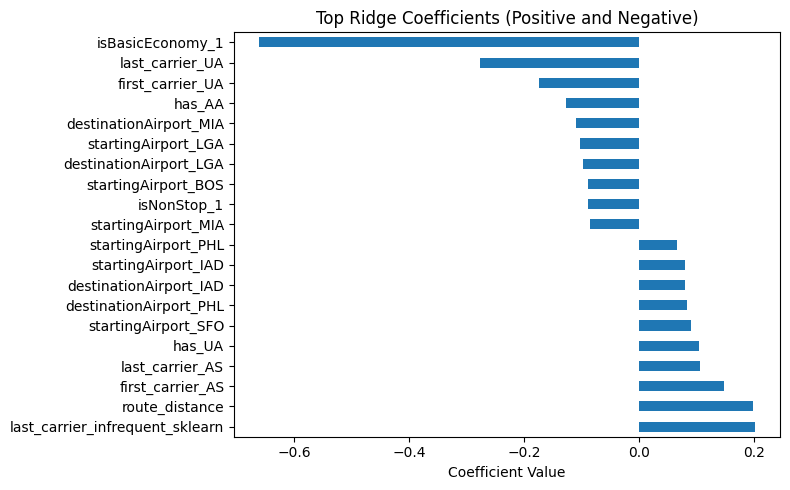

In [34]:
import matplotlib.pyplot as plt

top_features = pd.concat([coefs_sorted.head(10), coefs_sorted.tail(10)])
plt.figure(figsize=(8,5))
top_features.plot(kind='barh')
plt.title("Top Ridge Coefficients (Positive and Negative)")
plt.xlabel("Coefficient Value")
plt.tight_layout()
plt.show()


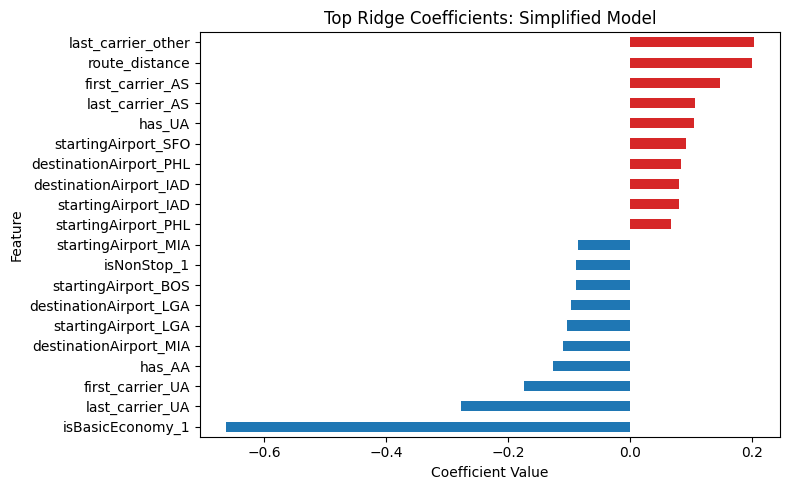

In [35]:
import matplotlib.pyplot as plt
import pandas as pd

coefs = pd.Series(pipe.named_steps['ridge'].coef_, index=feature_names)
coefs = pd.Series(ridge_model.coef_, index=feature_names)
coefs = coefs.rename(index=lambda x: x.replace('infrequent_sklearn', 'other'))
top_features = pd.concat([coefs.nlargest(10), coefs.nsmallest(10)])

plt.figure(figsize=(8,5))
top_features.sort_values().plot(kind='barh', color=['#1f77b4' if x > 0 else '#d62728' for x in top_features])
plt.title('Top Ridge Coefficients: Simplified Model')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


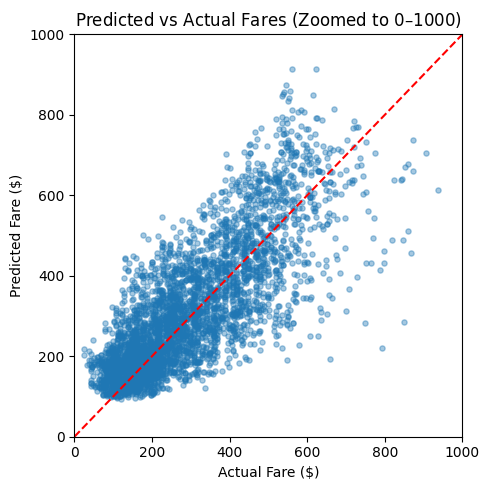

In [36]:
y_test_exp = np.exp(y_test)
pred_te_exp = np.exp(pipe.predict(X_test))

plt.figure(figsize=(5,5))
plt.scatter(y_test_exp, pred_te_exp, alpha=0.4, s=14)
plt.plot([0, 1000], [0, 1000], linestyle='--', color='red')
plt.xlim(0, 1000)
plt.ylim(0, 1000)
plt.xlabel('Actual Fare ($)')
plt.ylabel('Predicted Fare ($)')
plt.title('Predicted vs Actual Fares (Zoomed to $0–$1000)')
plt.tight_layout()
plt.show()

#LASSO

In [37]:
from sklearn.linear_model import LassoCV

# LASSO with cross-validated alpha (same alpha grid as before)
alphas = np.logspace(-3, 3, 40)

lasso = LassoCV(
    alphas=alphas,
    cv=5,
    random_state=0,
    max_iter=20000
)

lasso_pipe = Pipeline([
    ('pre', pre),     # same ColumnTransformer as before (with drop='first' in OHE)
    ('lasso', lasso)
])

# fit
lasso_pipe.fit(X_train, y_train)

# predictions
pred_tr_lasso = lasso_pipe.predict(X_train)
pred_te_lasso = lasso_pipe.predict(X_test)

# metrics (same style as ridge)
train_r2_lasso = r2_score(y_train, pred_tr_lasso)
test_r2_lasso  = r2_score(y_test,  pred_te_lasso)

# MAE and MAPE in original dollar space
mae_lasso = (np.exp(y_test) - np.exp(pred_te_lasso)).abs().mean()
mape_lasso = ((np.exp(pred_te_lasso) - np.exp(y_test)).abs() / np.exp(y_test)).mean() * 100

# clean dict (no np.float64 wrappers)
lasso_out = {
    "model": "LASSO",
    "alpha_*": float(lasso_pipe.named_steps['lasso'].alpha_),
    "Train_R2": float(train_r2_lasso),
    "Test_R2": float(test_r2_lasso),
    "Test_MAE_$": float(mae_lasso),
    "Test_MAPE_%": float(mape_lasso)
}

print(json.dumps(lasso_out, indent=2))


{
  "model": "LASSO",
  "alpha_*": 0.001,
  "Train_R2": 0.5536776629727465,
  "Test_R2": 0.5556863923745934,
  "Test_MAE_$": 84.12561837137919,
  "Test_MAPE_%": 35.31407428525015
}


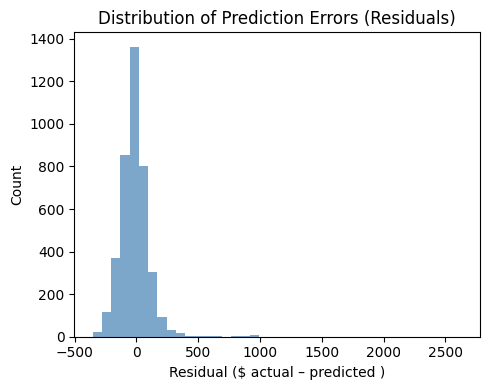

In [82]:
resid = np.exp(y_test) - np.exp(pred_te_lasso)

plt.figure(figsize=(5,4))
plt.hist(resid, bins=40, color="steelblue", alpha=0.7)
plt.title("Distribution of Prediction Errors (Residuals)")
plt.xlabel("Residual ($ actual – predicted )")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


Inspect model and zero coefficients

In [39]:
# 1. Get feature names from the preprocessor
pre = lasso_pipe.named_steps['pre']

try:
    feat_names = pre.get_feature_names_out()
except AttributeError:
    # Fallback if sklearn is older
    feat_names = []
    # numeric
    feat_names.extend([f"num__{c}" for c in num_feats])
    # categorical
    ohe = pre.named_transformers_['cat'].named_steps['ohe']
    cat_ohe_names = ohe.get_feature_names_out(cat_feats)
    feat_names.extend([f"cat__{n}" for n in cat_ohe_names])
    feat_names = np.array(feat_names)

# 2. Get coefficients
coef = lasso_pipe.named_steps['lasso'].coef_
intercept = lasso_pipe.named_steps['lasso'].intercept_

coef_df = pd.DataFrame({
    "feature": feat_names,
    "coef": coef
})

# 3. How sparse is it?
tol = 1e-6
coef_df["nonzero"] = coef_df["coef"].abs() > tol
nnz = coef_df["nonzero"].sum()
print(f"Non-zero coefficients: {nnz} / {len(coef_df)}")
print(f"Intercept: {intercept:.4f}")

# 4. Top positive / negative non-zero coefficients
top_pos = coef_df[coef_df["nonzero"]].sort_values("coef", ascending=False).head(15)
top_neg = coef_df[coef_df["nonzero"]].sort_values("coef", ascending=True).head(15)

print("\nTop positive coefficients:")
print(top_pos.to_string(index=False))

print("\nTop negative coefficients:")
print(top_neg.to_string(index=False))

Non-zero coefficients: 39 / 62
Intercept: 5.8364

Top positive coefficients:
                    feature     coef  nonzero
        num__route_distance 0.198820     True
     num__n_unique_carriers 0.080997     True
       cat__last_carrier_AS 0.080468     True
              num__num_legs 0.068099     True
   cat__startingAirport_SFO 0.065626     True
cat__destinationAirport_PHL 0.055357     True
cat__destinationAirport_IAD 0.050626     True
   cat__startingAirport_IAD 0.046502     True
      cat__first_carrier_AS 0.041545     True
   cat__startingAirport_PHL 0.038692     True
cat__destinationAirport_SFO 0.032799     True
   cat__startingAirport_LAX 0.023008     True
   cat__startingAirport_JFK 0.021459     True
        num__seatsRemaining 0.021015     True
                num__has_DL 0.015331     True

Top negative coefficients:
                    feature      coef  nonzero
      cat__isBasicEconomy_1 -0.655295     True
cat__destinationAirport_MIA -0.103271     True
              num_

In [41]:
# Get preprocessor and feature names
pre = lasso_pipe.named_steps['pre']

try:
    feature_names = pre.get_feature_names_out()
except AttributeError:
    # fallback if needed
    feature_names = []
    feature_names.extend([f"num__{c}" for c in num_feats])
    ohe = pre.named_transformers_['cat'].named_steps['ohe']
    cat_names = ohe.get_feature_names_out(cat_feats)
    feature_names.extend([f"cat__{c}" for c in cat_names])
    feature_names = np.array(feature_names)

# Coefficients
coef = lasso_pipe.named_steps['lasso'].coef_
intercept = lasso_pipe.named_steps['lasso'].intercept_

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coef
})
coef_df["abs_coef"] = coef_df["coef"].abs()
coef_df["is_zero"] = coef_df["abs_coef"] < 1e-8

n_total = len(coef_df)
n_nonzero = (~coef_df["is_zero"]).sum()
n_zero = n_total - n_nonzero

print(f"Total features: {n_total}")
print(f"Non-zero coefficients: {n_nonzero}")
print(f"Zero coefficients: {n_zero}")
print(f"Sparsity: {n_zero / n_total:.1%}")

zero_features = coef_df[coef_df["is_zero"]]["feature"].tolist()
nonzero_features = coef_df[~coef_df["is_zero"]].sort_values("abs_coef", ascending=False)

print("\nSome zeroed (dropped) features:")
print(zero_features[:15])

print("\nTop non-zero features:")
print(nonzero_features.head(15)[["feature", "coef"]])



Total features: 62
Non-zero coefficients: 39
Zero coefficients: 23
Sparsity: 37.1%

Some zeroed (dropped) features:
['num__n_carrier_changes', 'num__has_UA', 'num__has_NK', 'num__has_AS', 'cat__startingAirport_EWR', 'cat__destinationAirport_CLT', 'cat__destinationAirport_DEN', 'cat__destinationAirport_DFW', 'cat__destinationAirport_EWR', 'cat__destinationAirport_JFK', 'cat__destinationAirport_LAX', 'cat__destinationAirport_OAK', 'cat__destinationAirport_ORD', 'cat__first_carrier_B6', 'cat__first_carrier_DL']

Top non-zero features:
                        feature      coef
47        cat__isBasicEconomy_1 -0.655295
1           num__route_distance  0.198820
41  cat__destinationAirport_MIA -0.103271
14                num__has_ulcc -0.096784
25     cat__startingAirport_LGA -0.095321
40  cat__destinationAirport_LGA -0.091320
4        num__n_unique_carriers  0.080997
16     cat__startingAirport_BOS -0.080740
55         cat__last_carrier_AS  0.080468
26     cat__startingAirport_MIA -0.078601


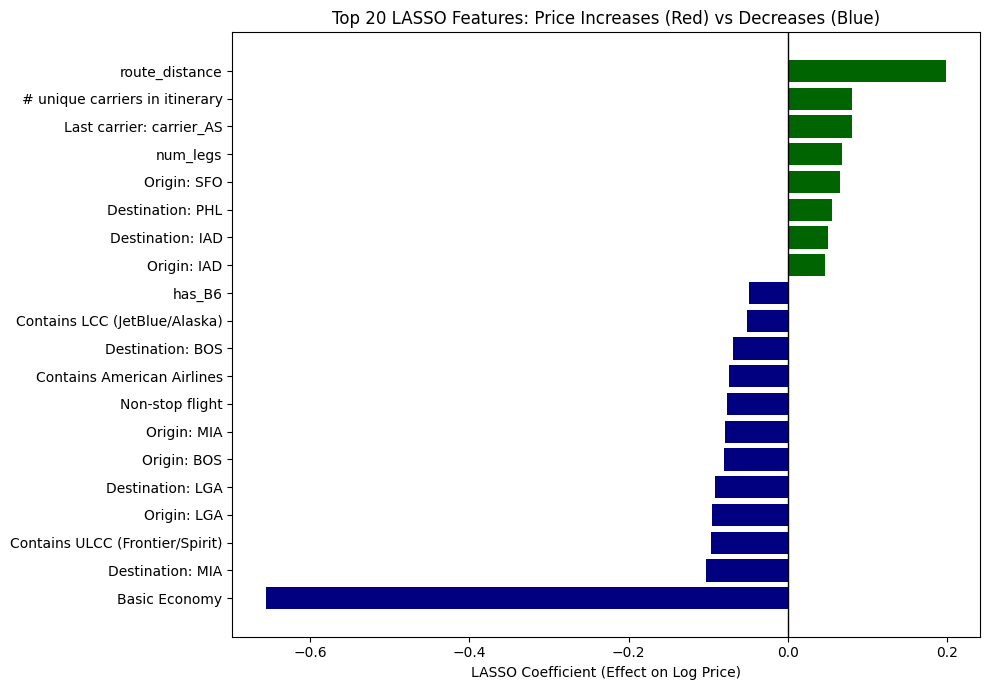

In [58]:
#visualization for top coefficients and coefficients magnitude

clean_names = []

for f in coef_df["feature"]:
    # remove pipeline prefixes
    f = f.replace("num__", "").replace("cat__", "")

    # fix one-hot naming (e.g., startingAirport_LGA → Origin: LGA)
    if f.startswith("startingAirport_"):
        airport = f.split("_", 1)[1]
        f = f"Origin: {airport}"

    elif f.startswith("destinationAirport_"):
        airport = f.split("_", 1)[1]
        f = f"Destination: {airport}"

    elif f.startswith("segmentsAirlineCode_"):
        carrier = f.split("_", 1)[1]
        f = f"Airline: {carrier}"

    elif f == "isNonStop_1":
        f = "Non-stop flight"

    elif f == "isBasicEconomy_1":
        f = "Basic Economy"

    elif f == "isRefundable_1":
        f = "Refundable ticket"

    elif f == "n_unique_carriers":
        f = "# unique carriers in itinerary"

    elif f == "has_ulcc":
        f = "Contains ULCC (Frontier/Spirit)"

    elif f == "has_lcc":
        f = "Contains LCC (JetBlue/Alaska)"

    elif f == "has_AA":
        f = "Contains American Airlines"

    elif f.startswith("last_carrier_"):
        carrier = f.split("_", 1)[1]
        f = f"Last carrier: {carrier}"

    clean_names.append(f)

coef_df["clean_name"] = clean_names

top_k = 20
# rebuild abs_coef and is_zero safely
coef_df["abs_coef"] = coef_df["coef"].abs()
coef_df["is_zero"] = coef_df["abs_coef"] < 1e-6   # threshold for zero

# 1. Take top |coef|, then sort by actual value (negative → positive)
top_coef = (
    coef_df[~coef_df["is_zero"]]
    .sort_values("abs_coef", ascending=False)
    .head(top_k)
    .sort_values("coef")   # negative at bottom, positive at top
)

# 2. Color by sign: red ↑ increases price, blue ↓ decreases price
colors = ["#006400" if c > 0 else "#000080" for c in top_coef["coef"]]

# 3. Plot horizontal bar chart
plt.figure(figsize=(10, 7))
y_pos = np.arange(len(top_coef))

plt.barh(y_pos, top_coef["coef"], color=colors)
plt.yticks(y_pos, top_coef["clean_name"])
plt.axvline(0, color="black", linewidth=1)

plt.xlabel("LASSO Coefficient (Effect on Log Price)")
plt.title("Top 20 LASSO Features: Price Increases (Red) vs Decreases (Blue)")
plt.tight_layout()
plt.show()


In [51]:
# 1. Extract feature names from the preprocessor
pre = lasso_pipe.named_steps['pre']

try:
    feat_names = pre.get_feature_names_out()
except:
    # Fallback construction if sklearn < 1.2
    num_names = [f"num__{c}" for c in num_feats]

    ohe = pre.named_transformers_['cat'].named_steps['ohe']
    cat_names = ohe.get_feature_names_out(cat_feats)

    feat_names = np.concatenate([num_names, cat_names])

# 2. Extract coefficients
coef = lasso_pipe.named_steps['lasso'].coef_
coef_df = pd.DataFrame({"feature": feat_names, "coef": coef})

# 3. Filter non-zero coefficients
tol = 1e-6
nz = coef_df[np.abs(coef_df["coef"]) > tol]

# 4. Top positive / negative
top_pos = nz.sort_values("coef", ascending=False).head(15)
top_neg = nz.sort_values("coef", ascending=True).head(15)

print("==== Top Positive Coefficients ====")
print(top_pos.to_string(index=False))

print("\n==== Top Negative Coefficients ====")
print(top_neg.to_string(index=False))


==== Top Positive Coefficients ====
                    feature     coef
        num__route_distance 0.198820
     num__n_unique_carriers 0.080997
       cat__last_carrier_AS 0.080468
              num__num_legs 0.068099
   cat__startingAirport_SFO 0.065626
cat__destinationAirport_PHL 0.055357
cat__destinationAirport_IAD 0.050626
   cat__startingAirport_IAD 0.046502
      cat__first_carrier_AS 0.041545
   cat__startingAirport_PHL 0.038692
cat__destinationAirport_SFO 0.032799
   cat__startingAirport_LAX 0.023008
   cat__startingAirport_JFK 0.021459
        num__seatsRemaining 0.021015
                num__has_DL 0.015331

==== Top Negative Coefficients ====
                    feature      coef
      cat__isBasicEconomy_1 -0.655295
cat__destinationAirport_MIA -0.103271
              num__has_ulcc -0.096784
   cat__startingAirport_LGA -0.095321
cat__destinationAirport_LGA -0.091320
   cat__startingAirport_BOS -0.080740
   cat__startingAirport_MIA -0.078601
           cat__isNonStop_1 -0.

We fit a LASSO model on the preprocessed features.

Out of 62 features, LASSO kept only 39, setting the rest exactly to zero.

#Key Positive Predictors (higher price)
1. Route characteristics

route_distance (0.20) — Longer trips cost more.

num_legs (0.07) — More segments → higher fare.

n_unique_carriers (0.08) — Mixed-carrier itineraries tend to be more expensive.

2. Airports associated with higher prices

SFO, IAD, PHL, LAX, JFK (positive coefficients)
→ These hubs generally correspond to higher-cost markets and premium routes.

3. Carriers associated with higher prices

Alaska Airlines (AS)
(first_carrier_AS, last_carrier_AS) — often mid/high fare structure.

has_DL (0.015) — Delta presence increases fare slightly.

4. Seat availability

seatsRemaining (0.02) — More remaining seats slightly increases log-price (weak effect, could reflect fare buckets).

#Key Negative Predictors (lower price)
1. Fare class

isBasicEconomy_1 (−0.655) — By far the largest effect; Basic Economy strongly lowers price.

2. Price-depressing airports

MIA, LGA, BOS
→ These airports show consistent negative coefficients; they tend to have more competitive or lower average fares on many routes.

3. ULCC / LCC influence (cheaper carriers)

has_ulcc (−0.097) — Presence of ULCCs (NK/F9/G4) reduces price.

has_lcc (−0.052) — LCCs (WN/B6/AS) pull prices down (but weaker than ULCCs).

has_AA, has_B6, has_F9 — Each shows negative effect, consistent with competitive fare structures.

4. Non-stop flights

isNonStop_1 (−0.076) — Surprisingly negative (usually non-stop is more expensive), meaning:

Given your feature set, non-stop routes are cheaper on average in your sample.

Likely reflects ULCC-dominated nonstop short-hauls.

5. United Airlines (UA)

first_carrier_UA and last_carrier_UA (around −0.04)
→ UA routes in this dataset lean cheaper.



In [64]:
# Display actual feature content by group
def show_group_content(group_name):
    df = coef_df[coef_df["group"] == group_name].copy()
    df["is_zero"] = df["coef"].abs() < 1e-6

    zeroed = df[df["is_zero"]]["clean_name"].tolist()
    kept   = df[~df["is_zero"]]["clean_name"].tolist()

    print(f"\n=== {group_name} ===")
    print("Non-zero:")
    for x in kept:
        print("  •", x)

    print("\nZero:")
    for x in zeroed:
        print("  •", x)

# show content for each group
for g in coef_df["group"].unique():
    show_group_content(g)



=== Numeric ===
Non-zero:
  • booking_window
  • route_distance
  • num_legs
  • seatsRemaining
  • # unique carriers in itinerary
  • Contains American Airlines
  • has_DL
  • has_B6
  • has_F9
  • has_9K
  • Contains ULCC (Frontier/Spirit)
  • Contains LCC (JetBlue/Alaska)
  • Origin: BOS
  • Origin: CLT
  • Origin: DEN
  • Origin: DFW
  • Origin: DTW
  • Origin: IAD
  • Origin: JFK
  • Origin: LAX
  • Origin: LGA
  • Origin: MIA
  • Origin: OAK
  • Origin: ORD
  • Origin: PHL
  • Origin: SFO
  • Destination: BOS
  • Destination: DTW
  • Destination: IAD
  • Destination: LGA
  • Destination: MIA
  • Destination: PHL
  • Destination: SFO
  • Non-stop flight
  • Basic Economy
  • first_carrier_AS
  • first_carrier_UA
  • Last carrier: carrier_AS
  • Last carrier: carrier_UA

Zero:
  • n_carrier_changes
  • has_UA
  • has_NK
  • has_AS
  • Origin: EWR
  • Destination: CLT
  • Destination: DEN
  • Destination: DFW
  • Destination: EWR
  • Destination: JFK
  • Destination: LAX
  • Destin

#insights from feature selection
#1
Looking at Origins:

Kept: BOS, CLT, DEN, DFW, DTW, IAD, JFK, LAX, LGA, MIA, OAK, ORD, PHL, SFO

Zeroed: EWR

**LASSO kept almost all Origin airports, meaning origin location has broad predictive power.**

But look at Destination:

Kept: BOS, DTW, IAD, LGA, MIA, PHL, SFO

Zeroed: CLT, DEN, DFW, EWR, JFK, LAX, OAK, ORD

**LASSO sees less signal in destination and drops half of them.**

Origins matter more than Destinations in LASSO model.
Interpretation based on US domestic fares: markets are often priced based on origin demand, not symmetric.

#2
LASSO earlier showed:

AS (Alaska) → strong price ↑

UA (United) → price ↓

ULCCs (NK, F9) → price ↓

B6, AA → competitive markets

Now compare to zero vs non-zero:

Non-zero

has_DL

has_B6

has_F9

has_9K

Contains ULCC

Contains LCC

first_carrier_AS, first_carrier_UA

last_carrier_AS, last_carrier_UA

Zero

has_NK

has_AS

many “last_carrier” and “first_carrier” for cheaper airlines (B6, F9, NK)
Pattern:
LASSO keeps one representative feature per carrier-type cluster, not every dummy.

Interpretation:
DL, AS, UA explain most of the variation in data and correlate with many other carrier flags.
The others add little once these are included.

Kept:

Basic Economy (strongest negative driver)

Non-stop flag (moderate negative effect)

Dropped:

number of carrier changes (weak signal)

Pattern:
Fare class & routing simplicity matter, but finer path complexity does not.

In [71]:
groups = []

for raw in coef_df["feature"]:
    f = raw.replace("num__", "").replace("cat__", "")

    if f.startswith("startingAirport_"):
        groups.append("Origin")
    elif f.startswith("destinationAirport_"):
        groups.append("Destination")
    elif f.startswith("first_carrier_"):
        groups.append("FirstCarrier")
    elif f.startswith("last_carrier_"):
        groups.append("LastCarrier")
    elif f.startswith("segmentsAirlineCode_"):
        groups.append("RawAirlineCombo")
    elif f.startswith("isNonStop"):
        groups.append("NonStopFlag")
    elif f.startswith("isBasicEconomy"):
        groups.append("BasicEconomyFlag")
    elif f.startswith("isRefundable"):
        groups.append("RefundableFlag")
    elif f.startswith("has_"):
        groups.append("CarrierPresenceFlag")
    else:
        groups.append("Numeric")

coef_df["group"] = groups

summary = (
    coef_df.assign(is_zero=lambda df: df["coef"].abs() < 1e-6)
    .groupby("group")["is_zero"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "Zero", "count": "Total"})
)

summary["Non-zero"] = summary["Total"] - summary["Zero"]
summary["% Kept"] = summary["Non-zero"] / summary["Total"] * 100
summary["% Dropped"] = summary["Zero"] / summary["Total"] * 100

summary.round(1)


,Zero,Total,Non-zero,% Kept,% Dropped
group,,,,,
BasicEconomyFlag,0,1,1,100.0,0.0
CarrierPresenceFlag,3,10,7,70.0,30.0
Destination,8,15,7,46.7,53.3
FirstCarrier,5,7,2,28.6,71.4
LastCarrier,5,7,2,28.6,71.4
NonStopFlag,0,1,1,100.0,0.0
Numeric,1,6,5,83.3,16.7
Origin,1,15,14,93.3,6.7


#elasticnet
didn't rlly improved performance

In [84]:
from sklearn.linear_model import ElasticNetCV
# alpha values (same as Ridge/LASSO)
alphas = np.logspace(-3, 3, 40)

# l1_ratio controls L1 vs L2 balance:
# 0 → Ridge-like
# 1 → LASSO-like
# middle → Elastic Net
l1_grid = [0.1, 0.3, 0.5, 0.7, 0.9]

enet = ElasticNetCV(
    l1_ratio=l1_grid,
    alphas=alphas,
    cv=5,
    max_iter=20000,
    random_state=0,
    n_jobs=-1
)

enet_pipe = Pipeline([
    ('pre', pre),     # same ColumnTransformer used for Ridge/LASSO
    ('enet', enet)
])

enet_pipe.fit(X_train, y_train)

pred_tr_enet = enet_pipe.predict(X_train)
pred_te_enet = enet_pipe.predict(X_test)

train_r2 = r2_score(y_train, pred_tr_enet)
test_r2  = r2_score(y_test,  pred_te_enet)

mae_enet = (np.exp(y_test) - np.exp(pred_te_enet)).abs().mean()
mape_enet = ((np.exp(pred_te_enet) - np.exp(y_test)).abs() / np.exp(y_test)).mean() * 100

enet_out = {
    "model": "ElasticNet",
    "alpha_*": float(enet_pipe.named_steps['enet'].alpha_),
    "l1_ratio_*": float(enet_pipe.named_steps['enet'].l1_ratio_),
    "Train_R2": float(train_r2),
    "Test_R2": float(test_r2),
    "Test_MAE_$": float(mae_enet),
    "Test_MAPE_%": float(mape_enet)
}

print(json.dumps(enet_out, indent=2))



{
  "model": "ElasticNet",
  "alpha_*": 0.001,
  "l1_ratio_*": 0.1,
  "Train_R2": 0.5574370794164869,
  "Test_R2": 0.5545217961079327,
  "Test_MAE_$": 84.66939372122654,
  "Test_MAPE_%": 35.44847859811508
}


#more market features

In [88]:
# ===== 1. Base prep =====
df = flight_sample.copy()

# dates & booking window
df['searchDate'] = pd.to_datetime(df['searchDate'], errors='coerce')
df['flightDate'] = pd.to_datetime(df['flightDate'], errors='coerce')
df = df.dropna(subset=['searchDate', 'flightDate', 'totalFare'])
df['booking_window'] = (df['flightDate'] - df['searchDate']).dt.days.clip(lower=0, upper=365)

# legs count from segments timing
def _count_legs(s):
    if pd.isna(s) or s == '':
        return 0
    return str(s).count('||') + 1

src_col = 'segmentsDepartureTimeRaw' if 'segmentsDepartureTimeRaw' in df.columns else (
          'segmentsDepartureTimeEpochSeconds' if 'segmentsDepartureTimeEpochSeconds' in df.columns else None)
df['num_legs'] = df[src_col].apply(_count_legs) if src_col else 1

# route distance (totalTravelDistance else sum(segmentsDistance))
def _sum_segments_nums(s):
    if pd.isna(s):
        return np.nan
    return np.nansum(pd.to_numeric(str(s).split('||'), errors='coerce'))

df['route_distance'] = pd.to_numeric(df.get('totalTravelDistance', np.nan), errors='coerce')
if 'segmentsDistance' in df.columns:
    seg_dist = df['segmentsDistance'].apply(_sum_segments_nums)
    df['route_distance'] = df['route_distance'].fillna(seg_dist)

# winsorize distance
if df['route_distance'].notna().any():
    q1, q99 = df['route_distance'].quantile([0.01, 0.99])
    df['route_distance'] = df['route_distance'].clip(lower=q1, upper=q99)

# clean booleans & seats
for c in ['isNonStop', 'isRefundable', 'isBasicEconomy']:
    if c in df.columns:
        df[c] = df[c].astype(int)

df['seatsRemaining'] = pd.to_numeric(df['seatsRemaining'], errors='coerce')

# target: log price
df = df[df['totalFare'].notna() & (df['totalFare'] > 0)]
df['log_price'] = np.log(df['totalFare'])

# ===== 2. Carrier-level engineered features =====
def parse_carriers(s):
    if pd.isna(s) or s == '':
        return []
    return [tok.strip() for tok in str(s).split('||') if tok.strip()]

ULCC = {'NK', 'F9', 'G4'}        # ultra low-cost
LCC  = {'WN', 'B6', 'AS'}        # low-cost-ish

df['carriers_list'] = df.get('segmentsAirlineCode', pd.Series(index=df.index, dtype=object)).apply(parse_carriers)

df['first_carrier']     = df['carriers_list'].apply(lambda xs: xs[0] if xs else np.nan)
df['last_carrier']      = df['carriers_list'].apply(lambda xs: xs[-1] if xs else np.nan)
df['n_unique_carriers'] = df['carriers_list'].apply(lambda xs: len(set(xs)))
df['n_carrier_changes'] = df['carriers_list'].apply(lambda xs: max(len(xs) - 1, 0)).astype(int)
df['has_ulcc']          = df['carriers_list'].apply(lambda xs: int(any(c in ULCC for c in xs)))
df['has_lcc']           = df['carriers_list'].apply(lambda xs: int(any(c in LCC  for c in xs)))

# top-M specific carriers (from TRAIN ONLY → later)
M = 8

# route id for grouping
df['route_id'] = df['startingAirport'] + '->' + df['destinationAirport']

# basic time features
df['month'] = df['flightDate'].dt.month
df['dow']   = df['flightDate'].dt.dayofweek

# ===== 3. Time-based split =====
df_sorted_idx = df.sort_values('flightDate').index
cut = int(len(df_sorted_idx) * 0.8)
train_idx, test_idx = df_sorted_idx[:cut], df_sorted_idx[cut:]

train_df = df.loc[train_idx]
test_df  = df.loc[test_idx]

# ===== 4. Market-level features (computed on TRAIN, mapped to all) =====
# route-level price benchmarks
route_median = train_df.groupby('route_id')['totalFare'].median()
route_mean   = train_df.groupby('route_id')['totalFare'].mean()

df['route_median_price'] = df['route_id'].map(route_median)
df['route_mean_price']   = df['route_id'].map(route_mean)

global_median = train_df['totalFare'].median()
global_mean   = train_df['totalFare'].mean()
df['route_median_price'] = df['route_median_price'].fillna(global_median)
df['route_mean_price']   = df['route_mean_price'].fillna(global_mean)

df['price_vs_route_median'] = df['totalFare'] / df['route_median_price']

# route-level competition / carrier structure
route_has_ulcc   = train_df.groupby('route_id')['has_ulcc'].max()
route_avg_ncar   = train_df.groupby('route_id')['n_unique_carriers'].mean()

df['route_has_ulcc']      = df['route_id'].map(route_has_ulcc).fillna(0).astype(int)
df['route_avg_ncarriers'] = df['route_id'].map(route_avg_ncar).fillna(
    train_df['n_unique_carriers'].mean()
)

# airport-level typical fares (origin/dest)
origin_median = train_df.groupby('startingAirport')['totalFare'].median()
dest_median   = train_df.groupby('destinationAirport')['totalFare'].median()

df['origin_median_fare'] = df['startingAirport'].map(origin_median).fillna(global_median)
df['dest_median_fare']   = df['destinationAirport'].map(dest_median).fillna(global_median)

# major hub flags
major_hubs = {'ATL','DFW','DEN','ORD','LAX','CLT','MIA','JFK','EWR','SFO'}
df['origin_is_hub'] = df['startingAirport'].isin(major_hubs).astype(int)
df['dest_is_hub']   = df['destinationAirport'].isin(major_hubs).astype(int)

# ===== 5. Top-M carrier presence flags (from TRAIN only) =====
train_carriers_flat = [c for xs in train_df['carriers_list'] for c in xs]
topM = [c for c, _ in Counter(train_carriers_flat).most_common(M)]

for c in topM:
    col = f'has_{c}'
    df[col] = df['carriers_list'].apply(lambda xs, cc=c: int(cc in xs))

# ===== 6. Final feature sets =====
num_feats = [
    'booking_window', 'route_distance', 'num_legs', 'seatsRemaining',
    'n_unique_carriers', 'n_carrier_changes',
    'has_ulcc', 'has_lcc'
] + [f'has_{c}' for c in topM] + [
    'route_median_price', 'route_mean_price', 'price_vs_route_median',
    'route_has_ulcc', 'route_avg_ncarriers',
    'origin_median_fare', 'dest_median_fare',
    'origin_is_hub', 'dest_is_hub',
    'month', 'dow'
]

cat_feats = [c for c in [
    'startingAirport', 'destinationAirport',
    'first_carrier', 'last_carrier',
    'isNonStop', 'isRefundable', 'isBasicEconomy'
] if c in df.columns]

X = df[num_feats + cat_feats]
y = df['log_price']

X_train, y_train = X.loc[train_idx], y.loc[train_idx]
X_test,  y_test  = X.loc[test_idx],  y.loc[test_idx]

# ===== 7. Preprocessor + Ridge model =====
pre = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale', StandardScaler())
        ]), num_feats),
        ('cat', Pipeline([
            ('impute', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(
                handle_unknown='ignore',
                drop='first',
                min_frequency=50  # collapse rare levels
            ))
        ]), cat_feats),
    ],
    remainder='drop'
)

alphas = np.logspace(-3, 3, 40)
ridge = RidgeCV(alphas=alphas, cv=5, scoring='neg_mean_absolute_error')

pipe = Pipeline([
    ('pre', pre),
    ('ridge', ridge)
])

pipe.fit(X_train, y_train)

# ===== 8. Evaluation =====
pred_tr = pipe.predict(X_train)
pred_te = pipe.predict(X_test)

train_r2 = r2_score(y_train, pred_tr)
test_r2  = r2_score(y_test,  pred_te)

mae = (np.exp(y_test) - np.exp(pred_te)).abs().mean()
mape = ((np.exp(pred_te) - np.exp(y_test)).abs() / np.exp(y_test)).mean() * 100

results = {
    "model": "Ridge + market features",
    "alpha_*": float(pipe.named_steps['ridge'].alpha_),
    "Train_R2": float(train_r2),
    "Test_R2": float(test_r2),
    "Test_MAE_$": float(mae),
    "Test_MAPE_%": float(mape),
    "topM_carriers_used": topM
}
results


{'model': 'Ridge + market features',
 'alpha_*': 0.41246263829013524,
 'Train_R2': 0.9001526877291947,
 'Test_R2': 0.883226291119508,
 'Test_MAE_$': 66.57249363963376,
 'Test_MAPE_%': 16.380200947489378,
 'topM_carriers_used': ['AA', 'DL', 'UA', 'B6', 'NK', 'AS', 'F9', '9K']}

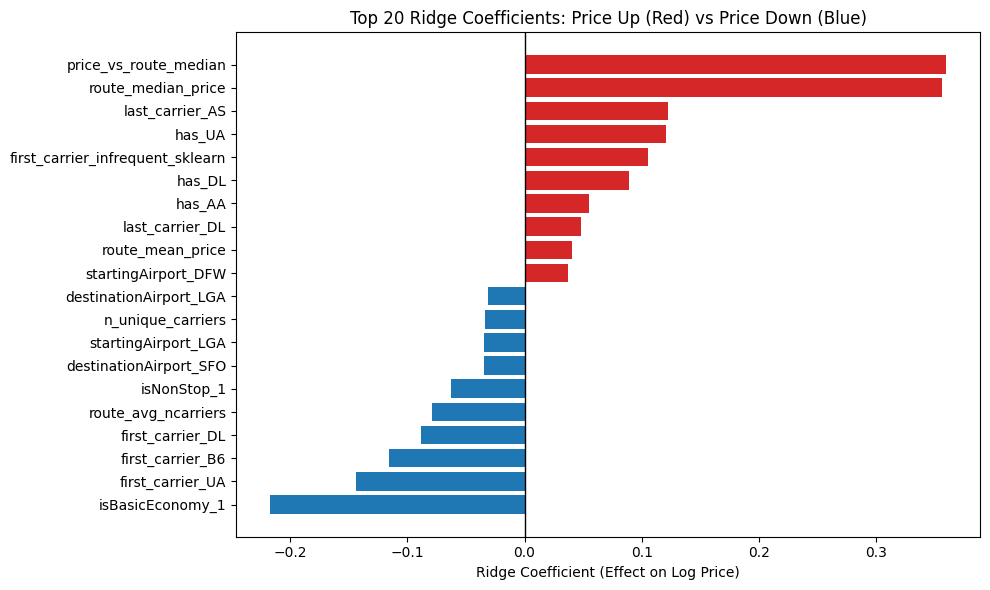

In [89]:
# 1. Get feature names from the preprocessor
pre = pipe.named_steps['pre']
ridge = pipe.named_steps['ridge']

feat_names = pre.get_feature_names_out()
coef = ridge.coef_

coef_df = pd.DataFrame({
    "feature": feat_names,
    "coef": coef
})
coef_df["abs_coef"] = coef_df["coef"].abs()

# optional: simple clean names (strip prefixes)
def clean_feature_name(f):
    f = f.replace("num__", "").replace("cat__", "")
    return f

coef_df["clean_name"] = coef_df["feature"].apply(clean_feature_name)

# 2. Take top-k by absolute value and sort by signed coef
top_k = 20
top_coef = (
    coef_df
    .sort_values("abs_coef", ascending=False)
    .head(top_k)
    .sort_values("coef")
)

# 3. Color by sign (red = price up, blue = price down)
colors = ["#d62728" if c > 0 else "#1f77b4" for c in top_coef["coef"]]

# 4. Plot
plt.figure(figsize=(10, 6))
y_pos = np.arange(len(top_coef))

plt.barh(y_pos, top_coef["coef"], color=colors)
plt.yticks(y_pos, top_coef["clean_name"])
plt.axvline(0, color="black", linewidth=1)

plt.xlabel("Ridge Coefficient (Effect on Log Price)")
plt.title("Top 20 Ridge Coefficients: Price Up (Red) vs Price Down (Blue)")
plt.tight_layout()
plt.show()


In [90]:
# Extract feature names after preprocessing
feat_names = pipe.named_steps['pre'].get_feature_names_out()
coef = pipe.named_steps['ridge'].coef_

# Build dataframe
coef_df = pd.DataFrame({
    "feature": feat_names,
    "coef": coef
})
coef_df["abs_coef"] = coef_df["coef"].abs()

# Clean feature names (optional)
def clean_name(f):
    return f.replace("num__", "").replace("cat__", "")
coef_df["clean_name"] = coef_df["feature"].apply(clean_name)

# Sort by coefficient
top_pos = coef_df.sort_values("coef", ascending=False).head(15)
top_neg = coef_df.sort_values("coef", ascending=True).head(15)

print("===== Top Positive Coefficients (Price ↑) =====")
print(top_pos[["clean_name", "coef"]])

print("\n===== Top Negative Coefficients (Price ↓) =====")
print(top_neg[["clean_name", "coef"]])


===== Top Positive Coefficients (Price ↑) =====
                          clean_name      coef
18             price_vs_route_median  0.359963
16                route_median_price  0.356457
64                   last_carrier_AS  0.122436
10                            has_UA  0.120466
63  first_carrier_infrequent_sklearn  0.105056
9                             has_DL  0.089256
8                             has_AA  0.054635
66                   last_carrier_DL  0.048155
17                  route_mean_price  0.040506
30               startingAirport_DFW  0.036697
45            destinationAirport_DFW  0.030011
11                            has_B6  0.029093
44            destinationAirport_DEN  0.028480
33               startingAirport_IAD  0.027900
39               startingAirport_ORD  0.026146

===== Top Negative Coefficients (Price ↓) =====
                clean_name      coef
72        isBasicEconomy_1 -0.217352
62        first_carrier_UA -0.143836
58        first_carrier_B6 -0.115378
59 

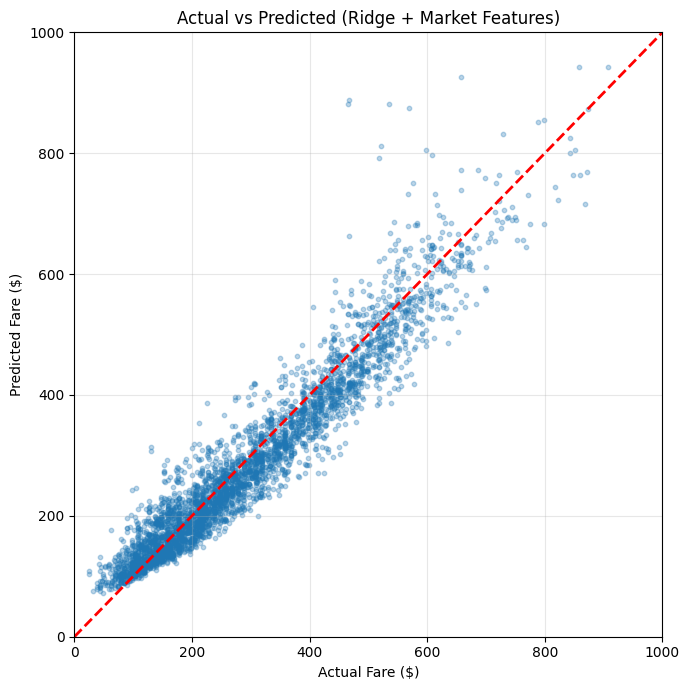

In [92]:
# Convert log-space predictions back to dollars
actual_price = np.exp(y_test)
pred_price   = np.exp(pred_te)

plt.figure(figsize=(7, 7))

# Scatter plot
plt.scatter(actual_price, pred_price, alpha=0.3, s=10)

# 45° reference line
lims = [
    0,
    1000
]
plt.plot(lims, lims, 'r--', linewidth=2)

plt.xlim(lims)
plt.ylim(lims)

plt.xlabel("Actual Fare ($)")
plt.ylabel("Predicted Fare ($)")
plt.title("Actual vs Predicted (Ridge + Market Features)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
